# LightGBM 랜덤 분할 모델링

            이 노트북은 `jswBad_2.csv` 데이터셋만 사용해 **공고의 특성으로 고연봉 여부(`high_salary`)를 예측**합니다.

            - 모델: `LightGBM`
            - 타겟: `high_salary`
            - 검증 방식: 전체 데이터 기준 랜덤 Train/Test 분할
            - 월 변수: `posting_month` 포함
            - 분기 변수: `quarter` 제외
            - 데이터 누수 방지: 타겟 컬럼과 `quarter`가 입력 피처에 들어가지 않았는지 코드로 검증

            `posting_month`는 월 기준 모델을 만들기 위해 입력 변수로 유지합니다. 반대로 `quarter`는 월에서 파생되는 중복 시간 변수이므로 제외합니다.

In [1]:
from pathlib import Path
import os
import warnings

PROJECT_DIR = Path(r"C:\Users\rdp-user\Desktop\3Team")
DATA_PATH = Path(r"C:\Users\rdp-user\Downloads\jswBad_2.csv")
OUTPUT_DIR = PROJECT_DIR / "05_month_modeling_no_quarter"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 한글 그래프와 matplotlib 캐시 문제가 동시에 생기지 않도록 프로젝트 내부 폴더를 사용합니다.
MPLCONFIGDIR = PROJECT_DIR / ".mplconfig"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPLCONFIGDIR)

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from IPython.display import display
from lightgbm import LGBMClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split

MODEL_NAME = "LightGBM"
TARGET_COL = "high_salary"
MONTH_FEATURE = "posting_month"
EXCLUDED_FEATURES = ["quarter"]
TEST_SIZE = 0.2
RANDOM_STATE = 42

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

# Windows/Anaconda 환경에서 한글 깨짐을 줄이기 위해 설치된 한글 폰트를 자동 선택합니다.
available_fonts = {font.name for font in fm.fontManager.ttflist}
for font_name in ["Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "AppleGothic"]:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False

print(f"모델: {MODEL_NAME}")
print(f"데이터 경로: {DATA_PATH}")

모델: LightGBM
데이터 경로: C:\Users\rdp-user\Downloads\jswBad_2.csv


## 1. 데이터 로드 및 기본 확인

            데이터 행/열 수, 결측치, 중복 행, 타겟 분포를 확인합니다.  
            모델링 전에 이 단계에서 데이터가 정상적으로 읽혔는지 확인합니다.

,항목,값
0,행 수,15000
1,열 수,34
2,전체 결측치 수,0
3,중복 행 수,0


,컬럼명,자료형
0,years_experience,int64
1,posting_month,int64
2,quarter,int64
3,experience_level,int64
4,education_required,int64
5,company_size,int64
6,job_title,int64
7,company_location,int64
8,industry,int64
9,skill_AWS,int64


,years_experience,posting_month,quarter,experience_level,education_required,company_size,job_title,company_location,industry,skill_AWS,skill_Azure,skill_Computer_Vision,skill_Data_Visualization,skill_Deep_Learning,skill_Docker,skill_GCP,skill_Git,skill_Hadoop,skill_Java,skill_Kubernetes,skill_Linux,skill_MLOps,skill_Mathematics,skill_NLP,skill_PyTorch,skill_Python,skill_R,skill_SQL,skill_Scala,skill_Spark,skill_Statistics,skill_Tableau,skill_TensorFlow,high_salary
0,13,202409,3,3,0,1,10,16,14,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1
1,10,202407,3,3,1,2,12,11,14,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,1
2,12,202501,1,3,1,0,9,7,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0
3,2,202407,3,1,3,2,7,5,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,0
4,0,202503,1,0,0,0,19,6,4,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0


,high_salary,count,percent
0,0,11250,75.0
1,1,3750,25.0


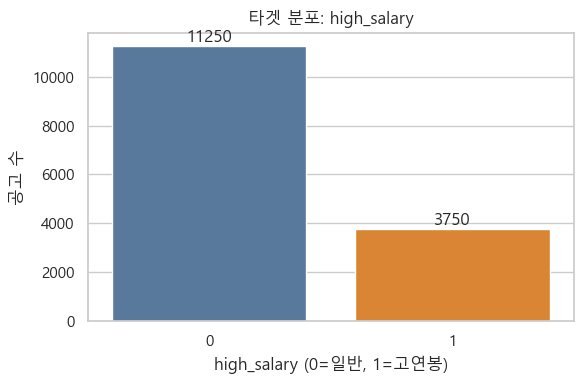

In [2]:
df = pd.read_csv(DATA_PATH)

basic_info = pd.DataFrame(
    {
        "항목": ["행 수", "열 수", "전체 결측치 수", "중복 행 수"],
        "값": [len(df), df.shape[1], int(df.isna().sum().sum()), int(df.duplicated().sum())],
    }
)
display(basic_info)

column_info = pd.DataFrame({"컬럼명": df.columns, "자료형": df.dtypes.astype(str).values})
display(column_info)

display(df.head())

target_distribution = (
    df[TARGET_COL]
    .value_counts()
    .sort_index()
    .rename_axis(TARGET_COL)
    .reset_index(name="count")
)
target_distribution["percent"] = (target_distribution["count"] / len(df) * 100).round(2)
display(target_distribution)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=target_distribution, x=TARGET_COL, y="count", ax=ax, palette=["#4C78A8", "#F58518"])
ax.set_title("타겟 분포: high_salary")
ax.set_xlabel("high_salary (0=일반, 1=고연봉)")
ax.set_ylabel("공고 수")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.tight_layout()
plt.show()

## 2. 피처/타겟 분리 및 데이터 누수 점검

            입력 피처는 데이터셋의 컬럼만 사용합니다.  
            `high_salary`는 정답이므로 입력에서 제외하고, `quarter`는 월 변수에서 파생되는 분기 변수이므로 제외합니다.  
            `posting_month`는 월 기준 예측을 위해 포함합니다.

In [3]:
assert TARGET_COL in df.columns, f"{TARGET_COL} 컬럼이 없습니다."
assert MONTH_FEATURE in df.columns, f"{MONTH_FEATURE} 컬럼이 없습니다."

feature_cols = [
    col for col in df.columns
    if col != TARGET_COL and col not in EXCLUDED_FEATURES
]

skill_cols = [col for col in feature_cols if col.startswith("skill_")]
categorical_cols = [
    col for col in [
        MONTH_FEATURE,
        "experience_level",
        "education_required",
        "company_size",
        "job_title",
        "company_location",
        "industry",
    ]
    if col in feature_cols
]
numeric_cols = [col for col in feature_cols if col not in categorical_cols]

assert TARGET_COL not in feature_cols, "타겟 high_salary가 입력 피처에 포함되어 있습니다."
assert "quarter" not in feature_cols, "quarter가 입력 피처에 포함되어 있습니다."
assert MONTH_FEATURE in feature_cols, "월 기준 모델인데 posting_month가 입력 피처에 없습니다."
assert set(feature_cols).issubset(set(df.columns)), "데이터셋에 없는 컬럼이 입력 피처에 포함되어 있습니다."

leakage_check = pd.DataFrame(
    {
        "점검 항목": [
            "타겟 high_salary 입력 제외",
            "분기 quarter 입력 제외",
            "월 posting_month 입력 포함",
            "데이터셋 컬럼만 사용",
            "입력 피처 결측치 없음",
        ],
        "결과": [
            TARGET_COL not in feature_cols,
            "quarter" not in feature_cols,
            MONTH_FEATURE in feature_cols,
            set(feature_cols).issubset(set(df.columns)),
            df[feature_cols].isna().sum().sum() == 0,
        ],
    }
)
display(leakage_check)

print(f"입력 피처 개수: {len(feature_cols)}")
print(f"스킬 피처 개수: {len(skill_cols)}")
print(f"범주형/코드형 피처: {categorical_cols}")
print(f"수치형/이진 피처 개수: {len(numeric_cols)}")
display(pd.DataFrame({"사용 피처": feature_cols}))

,점검 항목,결과
0,타겟 high_salary 입력 제외,True
1,분기 quarter 입력 제외,True
2,월 posting_month 입력 포함,True
3,데이터셋 컬럼만 사용,True
4,입력 피처 결측치 없음,True


입력 피처 개수: 32
스킬 피처 개수: 24
범주형/코드형 피처: ['posting_month', 'experience_level', 'education_required', 'company_size', 'job_title', 'company_location', 'industry']
수치형/이진 피처 개수: 25


,사용 피처
0,years_experience
1,posting_month
2,experience_level
3,education_required
4,company_size
5,job_title
6,company_location
7,industry
8,skill_AWS
9,skill_Azure


## 3. 월별 데이터 확인

            월별 공고 수와 실제 고연봉 비율을 확인합니다.  
            이는 모델 예측 결과가 아니라, 원본 데이터의 월별 분포를 보는 EDA입니다.

,posting_month,공고수,고연봉공고수,고연봉비율,고연봉비율_%
0,202401,883,224,0.253681,25.37
1,202402,869,224,0.257768,25.78
2,202403,1021,244,0.238981,23.90
3,202404,951,241,0.253417,25.34
4,202405,918,230,0.250545,25.05
5,202406,912,228,0.250000,25.00
6,202407,975,237,0.243077,24.31
7,202408,977,257,0.263050,26.31
8,202409,921,224,0.243214,24.32
9,202410,1006,252,0.250497,25.05


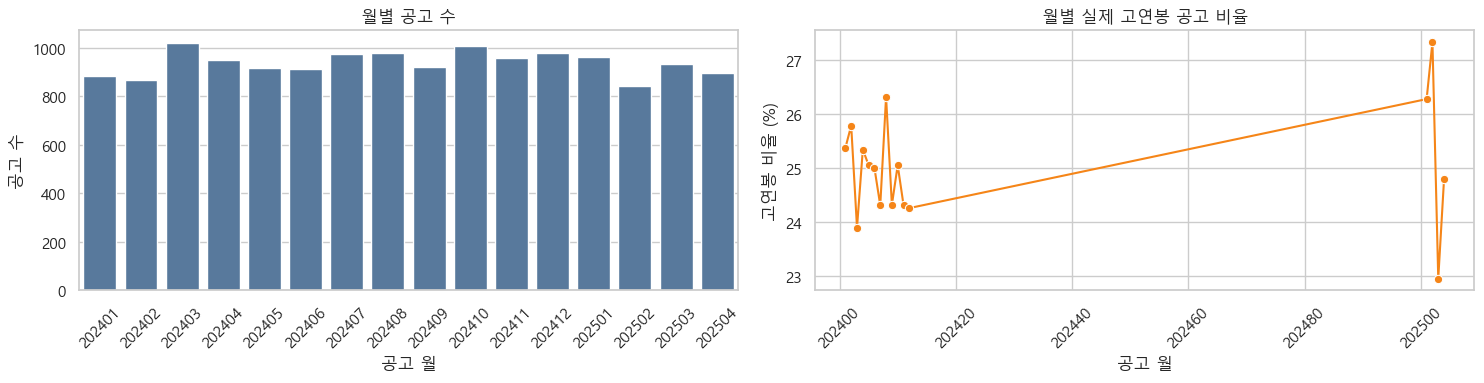

In [4]:
monthly_summary = (
    df.groupby(MONTH_FEATURE)
    .agg(
        공고수=(TARGET_COL, "size"),
        고연봉공고수=(TARGET_COL, "sum"),
        고연봉비율=(TARGET_COL, "mean"),
    )
    .reset_index()
    .sort_values(MONTH_FEATURE)
)
monthly_summary["고연봉비율_%"] = (monthly_summary["고연봉비율"] * 100).round(2)
display(monthly_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.barplot(data=monthly_summary, x=MONTH_FEATURE, y="공고수", ax=axes[0], color="#4C78A8")
axes[0].set_title("월별 공고 수")
axes[0].set_xlabel("공고 월")
axes[0].set_ylabel("공고 수")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=monthly_summary, x=MONTH_FEATURE, y="고연봉비율_%", marker="o", ax=axes[1], color="#F58518")
axes[1].set_title("월별 실제 고연봉 공고 비율")
axes[1].set_xlabel("공고 월")
axes[1].set_ylabel("고연봉 비율 (%)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 4. Train/Test 랜덤 분할

            전체 데이터에서 무작위로 Train/Test를 나눕니다.  
            `stratify=y`를 사용해 고연봉/일반 공고 비율이 학습셋과 테스트셋에서 비슷하게 유지되도록 합니다.

            LightGBM 설명: LightGBM은 빠르고 효율적인 그래디언트 부스팅 모델입니다. 많은 특성과 행을 가진 정형 데이터에서 학습 속도가 빠른 편입니다.

In [5]:
X = df[feature_cols].copy()
y = df[TARGET_COL].astype(int).copy()

# CatBoost는 범주형 피처를 직접 처리할 수 있으므로 코드형 범주 컬럼을 문자열로 변환합니다.
# 다른 모델은 숫자형 입력을 그대로 사용합니다.
if MODEL_NAME == "CatBoost":
    for col in categorical_cols:
        X[col] = X[col].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame(
    {
        "구분": ["Train", "Test"],
        "행 수": [len(X_train), len(X_test)],
        "high_salary=0 비율_%": [(1 - y_train.mean()) * 100, (1 - y_test.mean()) * 100],
        "high_salary=1 비율_%": [y_train.mean() * 100, y_test.mean() * 100],
    }
)
split_summary[["high_salary=0 비율_%", "high_salary=1 비율_%"]] = split_summary[
    ["high_salary=0 비율_%", "high_salary=1 비율_%"]
].round(2)
display(split_summary)

,구분,행 수,high_salary=0 비율_%,high_salary=1 비율_%
0,Train,12000,75.0,25.0
1,Test,3000,75.0,25.0


## 5. LightGBM 모델 학습

            아래 셀에서 모델을 학습합니다.  
            클래스 비율이 `0: 75%`, `1: 25%` 수준으로 불균형이 있으므로 모델별 불균형 보정 옵션을 사용합니다.

In [6]:
model = LGBMClassifier(
    n_estimators=450,
    learning_rate=0.04,
    max_depth=-1,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_metric=["auc", "binary_logloss"],
)

print("모델 학습 완료")

모델 학습 완료


## 6. 테스트 성능 지표

            Test 데이터에서 모델 성능을 수치로 확인합니다.

            - Accuracy: 전체 예측 중 맞힌 비율
            - Precision: 고연봉이라고 예측한 것 중 실제 고연봉인 비율
            - Recall: 실제 고연봉 공고 중 모델이 고연봉으로 잡아낸 비율
            - F1-score: Precision과 Recall의 균형 점수
            - ROC-AUC: 예측 확률 순위 기준 구분력
            - PR-AUC: 고연봉 클래스처럼 상대적으로 적은 클래스를 얼마나 잘 잡는지 보는 지표
            - Log Loss: 예측 확률이 실제 정답과 얼마나 차이 나는지 보는 지표

In [7]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

metrics_df = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "ROC-AUC",
            "PR-AUC",
            "Log Loss",
        ],
        "Value": [
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred, zero_division=0),
            recall_score(y_test, y_pred, zero_division=0),
            f1_score(y_test, y_pred, zero_division=0),
            roc_auc_score(y_test, y_pred_proba),
            average_precision_score(y_test, y_pred_proba),
            log_loss(y_test, y_pred_proba),
        ],
    }
)
metrics_df["Value"] = metrics_df["Value"].round(4)
display(metrics_df)

report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True, zero_division=0)).T
display(report_df.round(4))

,Metric,Value
0,Accuracy,0.9337
1,Precision,0.8156
2,Recall,0.9493
3,F1-score,0.8774
4,ROC-AUC,0.9802
5,PR-AUC,0.9371
6,Log Loss,0.1609


,precision,recall,f1-score,support
0,0.9821,0.9284,0.9545,2250.0000
1,0.8156,0.9493,0.8774,750.0000
accuracy,0.9337,0.9337,0.9337,0.9337
macro avg,0.8989,0.9389,0.9160,3000.0000
weighted avg,0.9405,0.9337,0.9352,3000.0000


## 7. 혼동행렬

            혼동행렬은 모델이 어떤 방향으로 맞고 틀렸는지 보여줍니다.

            - TN: 실제 일반 공고를 일반 공고로 맞힘
            - FP: 실제 일반 공고를 고연봉으로 잘못 예측
            - FN: 실제 고연봉 공고를 일반 공고로 놓침
            - TP: 실제 고연봉 공고를 고연봉으로 맞힘

,예측 0 일반,예측 1 고연봉
실제 0 일반,2089,161
실제 1 고연봉,38,712


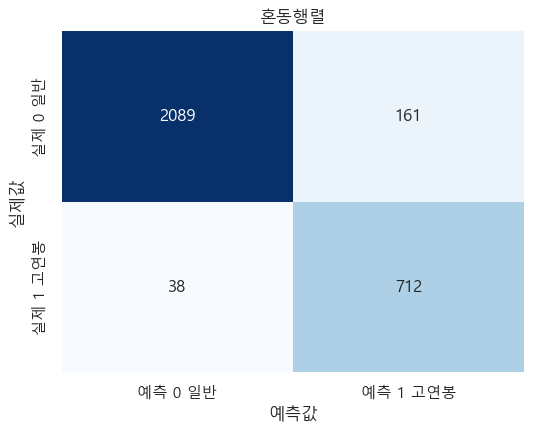

In [8]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["실제 0 일반", "실제 1 고연봉"],
    columns=["예측 0 일반", "예측 1 고연봉"],
)
display(cm_df)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("혼동행렬")
ax.set_xlabel("예측값")
ax.set_ylabel("실제값")
plt.tight_layout()
plt.show()

## 8. ROC 곡선과 Precision-Recall 곡선

            ROC 곡선은 전체 구분력을 보여주고, Precision-Recall 곡선은 고연봉 클래스 탐지 성능을 더 직접적으로 보여줍니다.

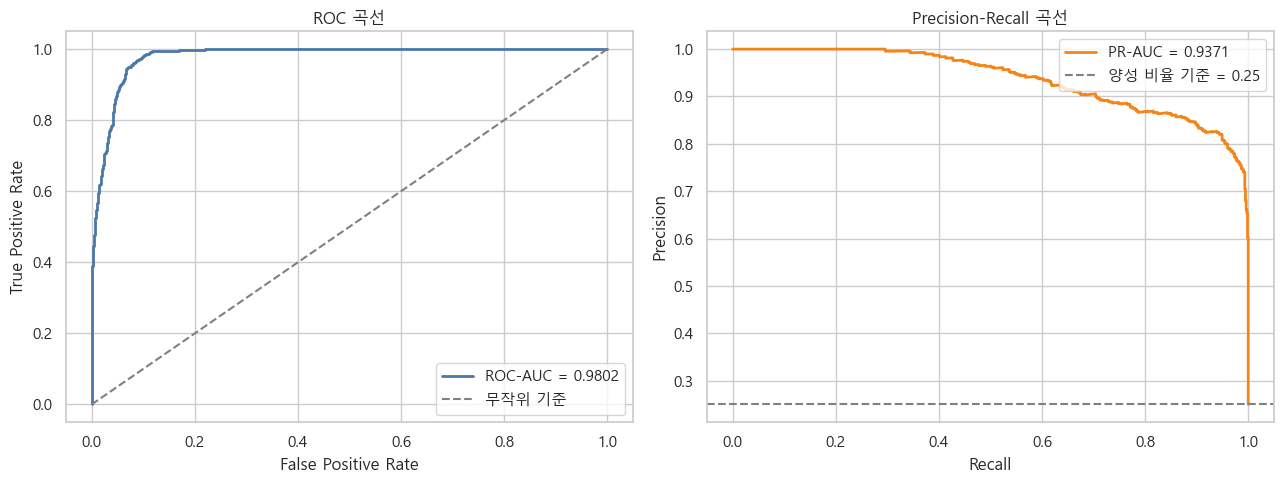

In [9]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_proba)
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color="#4C78A8", linewidth=2, label=f"ROC-AUC = {roc_auc:.4f}")
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", label="무작위 기준")
axes[0].set_title("ROC 곡선")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

axes[1].plot(recall_curve, precision_curve, color="#F58518", linewidth=2, label=f"PR-AUC = {pr_auc:.4f}")
axes[1].axhline(y_test.mean(), color="gray", linestyle="--", label=f"양성 비율 기준 = {y_test.mean():.2f}")
axes[1].set_title("Precision-Recall 곡선")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 9. 임계값별 성능 곡선

            기본 임계값은 0.5입니다.  
            고연봉 후보를 더 많이 잡는 것이 중요하면 Recall을 보고, 정말 확실한 고연봉 후보만 잡고 싶으면 Precision을 봅니다.

,threshold,accuracy,precision,recall,f1,predicted_positive_rate
0,0.05,0.8793,0.6754,0.9960,0.8050,0.3687
1,0.10,0.9023,0.7212,0.9933,0.8357,0.3443
2,0.15,0.9120,0.7430,0.9907,0.8491,0.3333
3,0.20,0.9167,0.7551,0.9867,0.8555,0.3267
4,0.25,0.9190,0.7632,0.9800,0.8581,0.3210
5,0.30,0.9223,0.7741,0.9733,0.8624,0.3143
6,0.35,0.9253,0.7846,0.9667,0.8662,0.3080
7,0.40,0.9270,0.7914,0.9613,0.8682,0.3037
8,0.45,0.9297,0.8018,0.9547,0.8716,0.2977
9,0.50,0.9337,0.8156,0.9493,0.8774,0.2910


F1 기준 최적 임계값


,threshold,accuracy,precision,recall,f1,predicted_positive_rate
10,0.55,0.9347,0.8244,0.9387,0.8778,0.2847


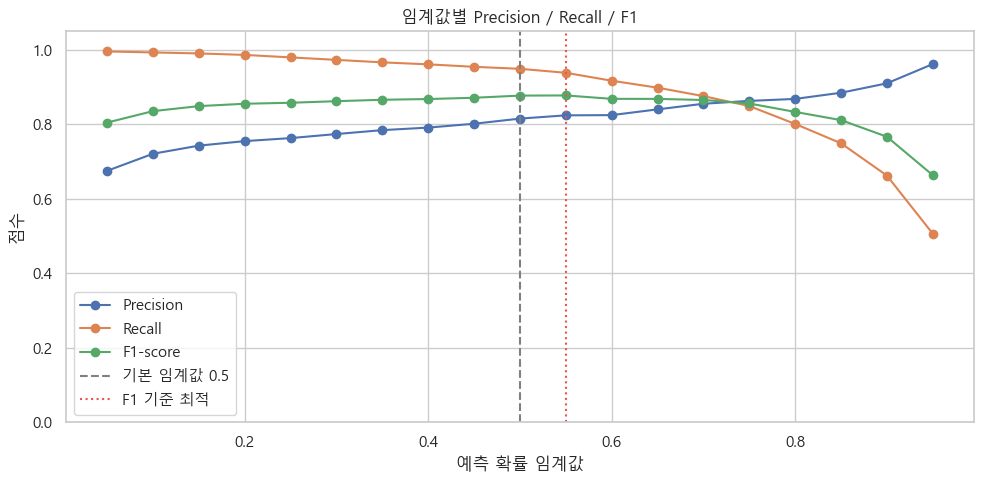

In [10]:
threshold_rows = []
for threshold in np.arange(0.05, 0.96, 0.05):
    pred_at_threshold = (y_pred_proba >= threshold).astype(int)
    threshold_rows.append(
        {
            "threshold": threshold,
            "accuracy": accuracy_score(y_test, pred_at_threshold),
            "precision": precision_score(y_test, pred_at_threshold, zero_division=0),
            "recall": recall_score(y_test, pred_at_threshold, zero_division=0),
            "f1": f1_score(y_test, pred_at_threshold, zero_division=0),
            "predicted_positive_rate": pred_at_threshold.mean(),
        }
    )

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.round(4))

best_threshold_row = threshold_df.loc[threshold_df["f1"].idxmax()]
print("F1 기준 최적 임계값")
display(best_threshold_row.to_frame().T.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
ax.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
ax.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1-score")
ax.axvline(0.5, color="gray", linestyle="--", label="기본 임계값 0.5")
ax.axvline(best_threshold_row["threshold"], color="#E45756", linestyle=":", label="F1 기준 최적")
ax.set_title("임계값별 Precision / Recall / F1")
ax.set_xlabel("예측 확률 임계값")
ax.set_ylabel("점수")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

## 10. 예측 확률 분포와 보정 곡선

            예측 확률 분포는 실제 일반/고연봉 공고가 어느 확률대에 몰리는지 보여줍니다.  
            보정 곡선은 예측 확률과 실제 고연봉 비율이 얼마나 가까운지 확인하는 그래프입니다.

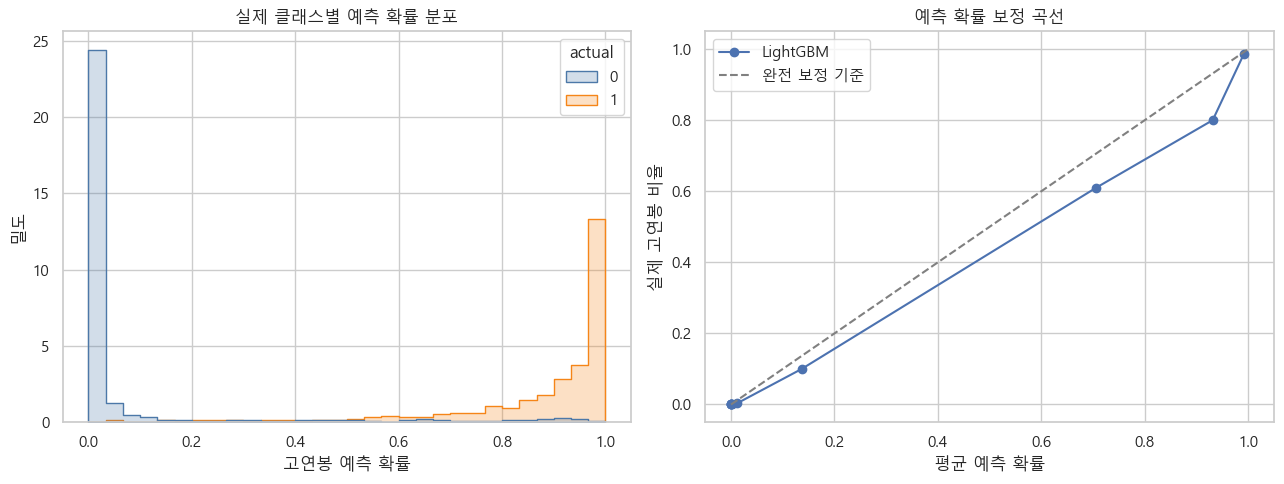

In [11]:
probability_df = pd.DataFrame(
    {
        "actual": y_test.values,
        "predicted_probability": y_pred_proba,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(
    data=probability_df,
    x="predicted_probability",
    hue="actual",
    bins=30,
    stat="density",
    common_norm=False,
    element="step",
    ax=axes[0],
    palette=["#4C78A8", "#F58518"],
)
axes[0].set_title("실제 클래스별 예측 확률 분포")
axes[0].set_xlabel("고연봉 예측 확률")
axes[0].set_ylabel("밀도")

prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10, strategy="quantile")
axes[1].plot(prob_pred, prob_true, marker="o", label=MODEL_NAME)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="완전 보정 기준")
axes[1].set_title("예측 확률 보정 곡선")
axes[1].set_xlabel("평균 예측 확률")
axes[1].set_ylabel("실제 고연봉 비율")
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. 학습 과정 또는 학습 데이터 크기별 곡선

            부스팅 모델은 반복 학습 과정의 Train/Test 지표 변화를 확인합니다.  
            RandomForest는 반복 학습 곡선이 없으므로 학습 데이터 크기별 ROC-AUC 변화를 확인합니다.

,dataset,metric,points
0,training,auc,450
1,training,binary_logloss,450
2,valid_1,auc,450
3,valid_1,binary_logloss,450


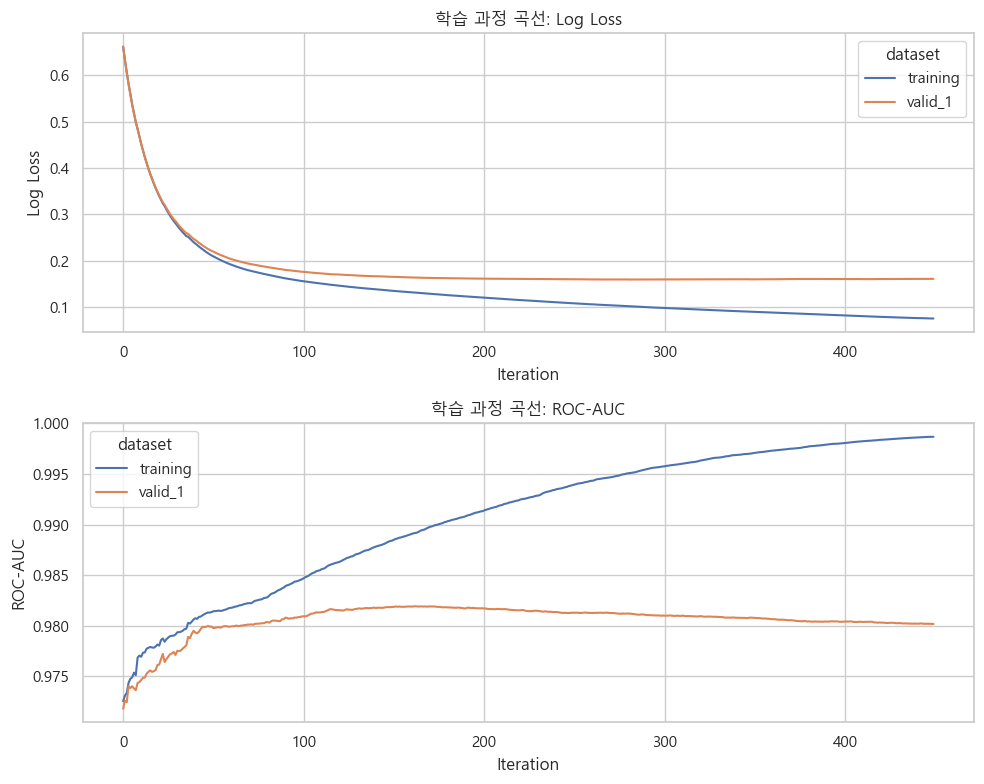

In [12]:
evals_result = model.evals_result_
curve_rows = []
for dataset_name, metric_dict in evals_result.items():
    for metric_name, values in metric_dict.items():
        for iteration, value in enumerate(values):
            curve_rows.append(
                {
                    "dataset": dataset_name,
                    "metric": metric_name,
                    "iteration": iteration,
                    "value": value,
                }
            )
learning_curve_df = pd.DataFrame(curve_rows)
display(learning_curve_df.groupby(["dataset", "metric"]).size().reset_index(name="points"))

metric_label_map = {"binary_logloss": "Log Loss", "auc": "ROC-AUC"}
plot_metrics = [metric for metric in ["binary_logloss", "auc"] if metric in learning_curve_df["metric"].unique()]

fig, axes = plt.subplots(len(plot_metrics), 1, figsize=(10, 4 * len(plot_metrics)))
if len(plot_metrics) == 1:
    axes = [axes]
for ax, metric_name in zip(axes, plot_metrics):
    subset = learning_curve_df[learning_curve_df["metric"] == metric_name]
    sns.lineplot(data=subset, x="iteration", y="value", hue="dataset", ax=ax)
    ax.set_title(f"학습 과정 곡선: {metric_label_map.get(metric_name, metric_name)}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel(metric_label_map.get(metric_name, metric_name))
plt.tight_layout()
plt.show()

## 12. Feature Importance

            Feature Importance는 모델이 예측할 때 어떤 입력 변수를 상대적으로 많이 활용했는지 보여줍니다.  
            값이 높다고 해서 인과관계를 의미하지는 않습니다. “모델이 예측에 많이 참고한 변수”로 해석해야 합니다.

,feature,importance
6,company_location,3030
0,years_experience,1670
5,job_title,1370
1,posting_month,1312
7,industry,1182
4,company_size,798
3,education_required,506
18,skill_Kubernetes,230
24,skill_Python,203
26,skill_SQL,185


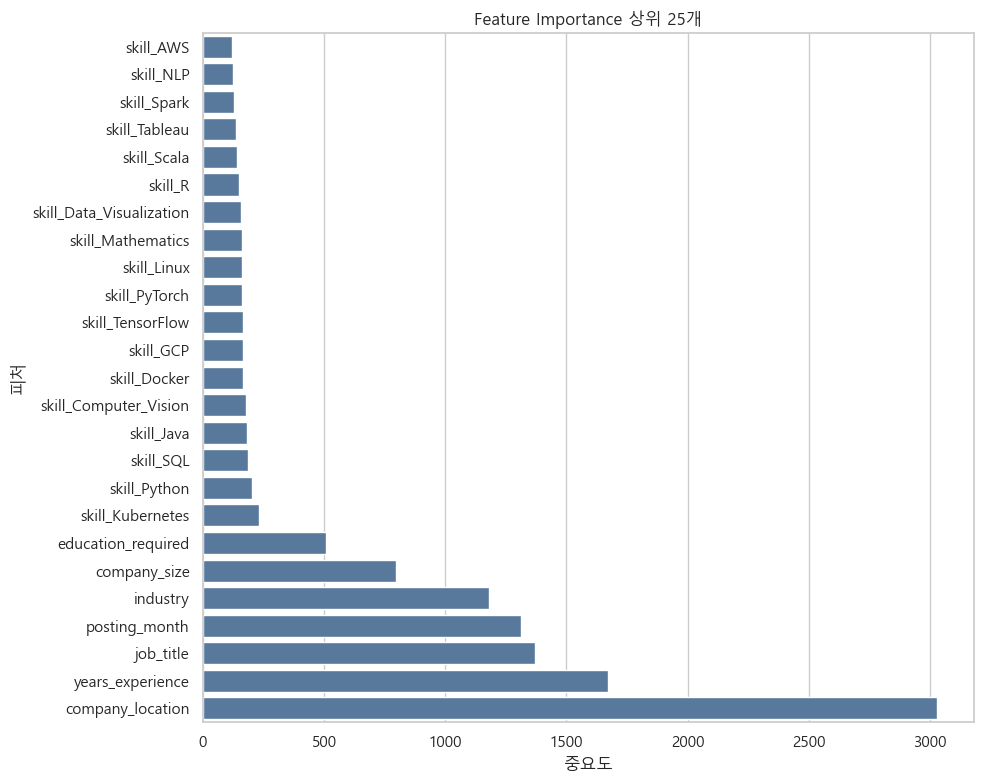

,feature,importance
18,skill_Kubernetes,230
24,skill_Python,203
26,skill_SQL,185
17,skill_Java,180
10,skill_Computer_Vision,179
13,skill_Docker,167
14,skill_GCP,164
31,skill_TensorFlow,164
19,skill_Linux,162
23,skill_PyTorch,162


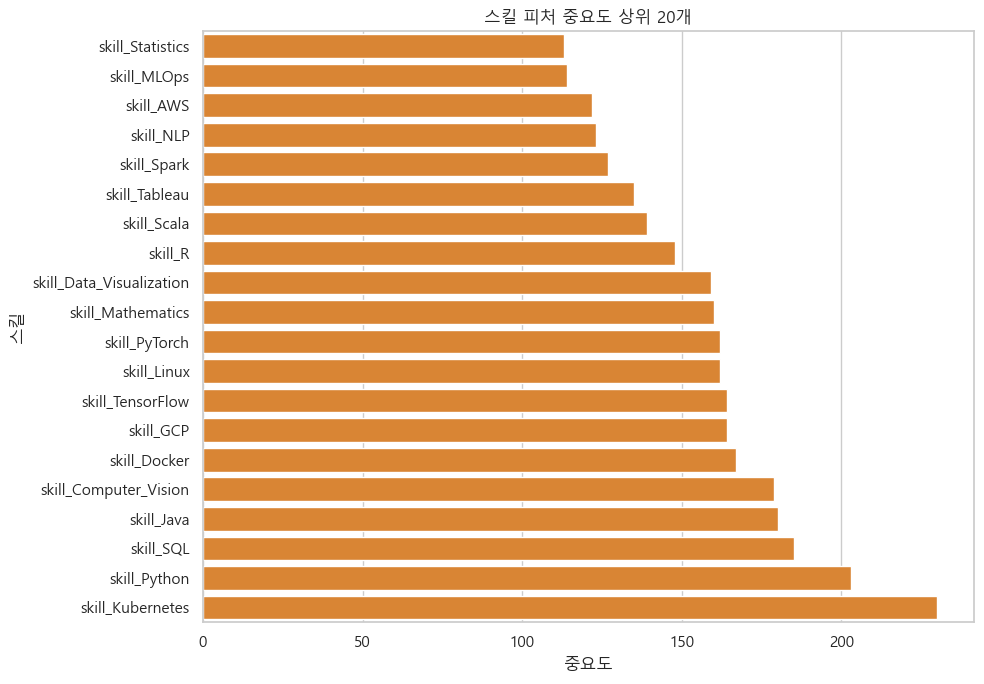

In [13]:
feature_importance = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance": model.feature_importances_,
    }
).sort_values("importance", ascending=False)

display(feature_importance.head(30).round(4))

fig, ax = plt.subplots(figsize=(10, 8))
top_importance = feature_importance.head(25).sort_values("importance", ascending=True)
sns.barplot(data=top_importance, x="importance", y="feature", ax=ax, color="#4C78A8")
ax.set_title("Feature Importance 상위 25개")
ax.set_xlabel("중요도")
ax.set_ylabel("피처")
plt.tight_layout()
plt.show()

skill_importance = feature_importance[feature_importance["feature"].str.startswith("skill_")].copy()
display(skill_importance.head(20).round(4))

fig, ax = plt.subplots(figsize=(10, 7))
top_skill_importance = skill_importance.head(20).sort_values("importance", ascending=True)
sns.barplot(data=top_skill_importance, x="importance", y="feature", ax=ax, color="#F58518")
ax.set_title("스킬 피처 중요도 상위 20개")
ax.set_xlabel("중요도")
ax.set_ylabel("스킬")
plt.tight_layout()
plt.show()

## 13. 월별 테스트 예측 결과

            Test 데이터에서 월별 실제 고연봉 비율과 모델의 평균 예측 확률을 비교합니다.  
            `posting_month`를 포함한 모델이 월별로 어떤 예측 흐름을 보이는지 확인합니다.

,posting_month,테스트공고수,실제고연봉비율,평균예측확률,예측고연봉비율_임계값0_5,실제고연봉비율_%,평균예측확률_%,예측고연봉비율_임계값0_5_%
0,202401,179,0.296089,0.338047,0.346369,29.61,33.80,34.64
1,202402,172,0.209302,0.256576,0.255814,20.93,25.66,25.58
2,202403,197,0.223350,0.240734,0.253807,22.34,24.07,25.38
3,202404,198,0.292929,0.318718,0.323232,29.29,31.87,32.32
4,202405,190,0.278947,0.309445,0.331579,27.89,30.94,33.16
5,202406,182,0.230769,0.242661,0.247253,23.08,24.27,24.73
6,202407,193,0.238342,0.258165,0.279793,23.83,25.82,27.98
7,202408,200,0.275000,0.303419,0.330000,27.50,30.34,33.00
8,202409,181,0.232044,0.286492,0.298343,23.20,28.65,29.83
9,202410,202,0.193069,0.226411,0.227723,19.31,22.64,22.77


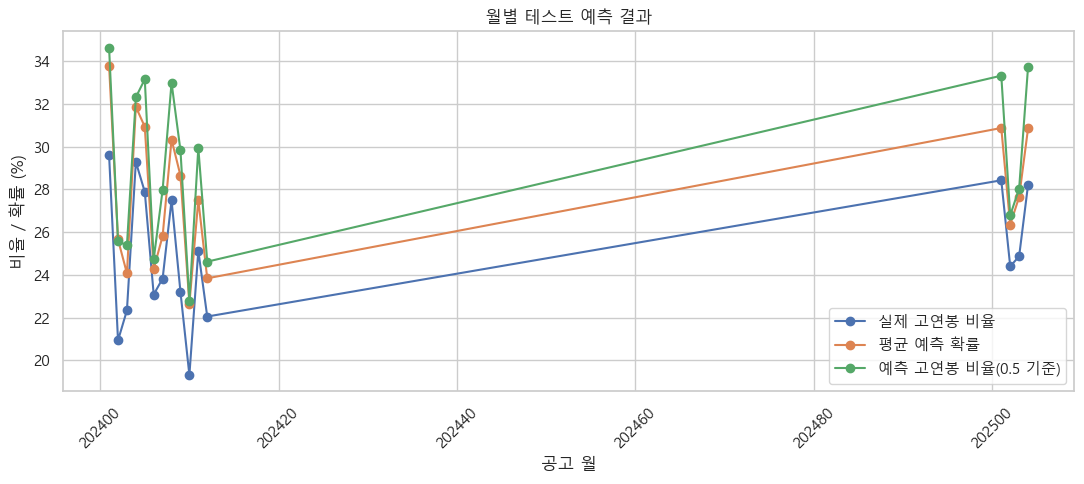

In [14]:
test_result_df = X_test.copy()
test_result_df["actual_high_salary"] = y_test.values
test_result_df["predicted_probability"] = y_pred_proba
test_result_df["predicted_label_0_5"] = y_pred

monthly_test_result = (
    test_result_df.groupby(MONTH_FEATURE)
    .agg(
        테스트공고수=("actual_high_salary", "size"),
        실제고연봉비율=("actual_high_salary", "mean"),
        평균예측확률=("predicted_probability", "mean"),
        예측고연봉비율_임계값0_5=("predicted_label_0_5", "mean"),
    )
    .reset_index()
    .sort_values(MONTH_FEATURE)
)
for col in ["실제고연봉비율", "평균예측확률", "예측고연봉비율_임계값0_5"]:
    monthly_test_result[f"{col}_%"] = (monthly_test_result[col] * 100).round(2)

display(monthly_test_result)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    monthly_test_result[MONTH_FEATURE],
    monthly_test_result["실제고연봉비율_%"],
    marker="o",
    label="실제 고연봉 비율",
)
ax.plot(
    monthly_test_result[MONTH_FEATURE],
    monthly_test_result["평균예측확률_%"],
    marker="o",
    label="평균 예측 확률",
)
ax.plot(
    monthly_test_result[MONTH_FEATURE],
    monthly_test_result["예측고연봉비율_임계값0_5_%"],
    marker="o",
    label="예측 고연봉 비율(0.5 기준)",
)
ax.set_title("월별 테스트 예측 결과")
ax.set_xlabel("공고 월")
ax.set_ylabel("비율 / 확률 (%)")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## 14. Stratified K-Fold 교차검증

단일 Train/Test 분할 결과가 우연에 치우치지 않았는지 확인하기 위해 **Stratified K-Fold 교차검증**을 실행합니다.

`Stratified K-Fold`는 각 Fold마다 `high_salary=0`과 `high_salary=1`의 비율을 최대한 비슷하게 유지하면서 데이터를 나누는 방식입니다.  
이 데이터처럼 고연봉 공고 비율이 25% 정도로 불균형한 분류 문제에서는 일반 K-Fold보다 더 안정적인 검증 방식입니다.

- Fold 수: 5
- 각 Fold에서 학습/검증을 반복
- 검증 지표: Accuracy, Precision, Recall, F1-score, ROC-AUC, PR-AUC
- 입력 변수 기준: `posting_month` 포함, `quarter` 제외

,fold,train_size,valid_size,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,1,12000,3000,0.9257,0.7944,0.9480,0.8644,0.9820,0.9448
1,2,12000,3000,0.9293,0.8029,0.9507,0.8706,0.9802,0.9351
2,3,12000,3000,0.9333,0.8097,0.9587,0.8779,0.9815,0.9396
3,4,12000,3000,0.9270,0.8027,0.9387,0.8654,0.9815,0.9436
4,5,12000,3000,0.9167,0.7723,0.9453,0.8501,0.9749,0.9240


,Metric,Mean,Std
0,Accuracy,0.9264,0.0062
1,Precision,0.7964,0.0145
2,Recall,0.9483,0.0073
3,F1-score,0.8657,0.0102
4,ROC-AUC,0.9800,0.0029
5,PR-AUC,0.9374,0.0084


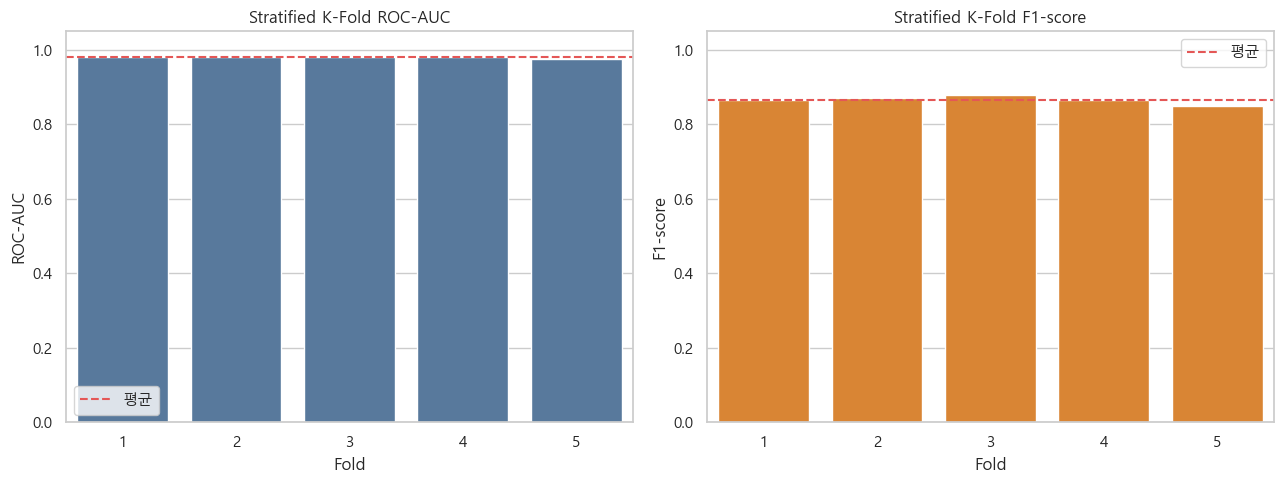

Stratified K-Fold 교차검증 결과 저장 완료
Fold별 결과 CSV: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\model_artifacts\LightGBM_RandomSplit_Month_stratified_kfold_metrics.csv
요약 결과 CSV: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\model_artifacts\LightGBM_RandomSplit_Month_stratified_kfold_summary.csv


In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

    cv_model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.04,
        max_depth=-1,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        class_weight="balanced",
        random_state=RANDOM_STATE + fold,
        n_jobs=1,
        verbose=-1,
    )
    cv_model.fit(X_tr, y_tr)

    val_proba = cv_model.predict_proba(X_val)[:, 1]
    val_pred = (val_proba >= 0.5).astype(int)

    cv_rows.append(
        {
            "fold": fold,
            "train_size": len(X_tr),
            "valid_size": len(X_val),
            "Accuracy": accuracy_score(y_val, val_pred),
            "Precision": precision_score(y_val, val_pred, zero_division=0),
            "Recall": recall_score(y_val, val_pred, zero_division=0),
            "F1-score": f1_score(y_val, val_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_val, val_proba),
            "PR-AUC": average_precision_score(y_val, val_proba),
        }
    )

cv_df = pd.DataFrame(cv_rows)
display(cv_df.round(4))

cv_summary = cv_df.drop(columns=["fold", "train_size", "valid_size"]).agg(["mean", "std"]).T.reset_index()
cv_summary.columns = ["Metric", "Mean", "Std"]
display(cv_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=cv_df, x="fold", y="ROC-AUC", ax=axes[0], color="#4C78A8")
axes[0].axhline(cv_df["ROC-AUC"].mean(), color="#E45756", linestyle="--", label="평균")
axes[0].set_title("Stratified K-Fold ROC-AUC")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("ROC-AUC")
axes[0].set_ylim(0, 1.05)
axes[0].legend()

sns.barplot(data=cv_df, x="fold", y="F1-score", ax=axes[1], color="#F58518")
axes[1].axhline(cv_df["F1-score"].mean(), color="#E45756", linestyle="--", label="평균")
axes[1].set_title("Stratified K-Fold F1-score")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("F1-score")
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

artifact_dir = OUTPUT_DIR / "model_artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)
cv_metrics_path = artifact_dir / f"{MODEL_NAME}_RandomSplit_Month_stratified_kfold_metrics.csv"
cv_summary_path = artifact_dir / f"{MODEL_NAME}_RandomSplit_Month_stratified_kfold_summary.csv"
cv_df.to_csv(cv_metrics_path, index=False, encoding="utf-8-sig")
cv_summary.to_csv(cv_summary_path, index=False, encoding="utf-8-sig")

print("Stratified K-Fold 교차검증 결과 저장 완료")
print(f"Fold별 결과 CSV: {cv_metrics_path}")
print(f"요약 결과 CSV: {cv_summary_path}")

## 15. 발표/노션용 시각화 강화

아래 시각화는 발표 자료나 노션 정리본에 바로 넣기 좋도록 만든 그래프입니다.  
노트북 안에 표시될 뿐 아니라 `visualizations/{모델명}` 폴더에 PNG 이미지로도 저장됩니다.

- 성능 지표 막대그래프
- 정규화 혼동행렬
- ROC / Precision-Recall / 보정 곡선 통합 대시보드
- 임계값별 Precision, Recall, F1 변화
- 전체 Feature Importance와 스킬 Feature Importance
- 월별 실제 비율과 평균 예측 확률 비교
- Stratified K-Fold 평균 ± 표준편차와 Fold별 점수 변화

이미지 저장: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\visualizations\LightGBM\01_test_metrics_bar.png


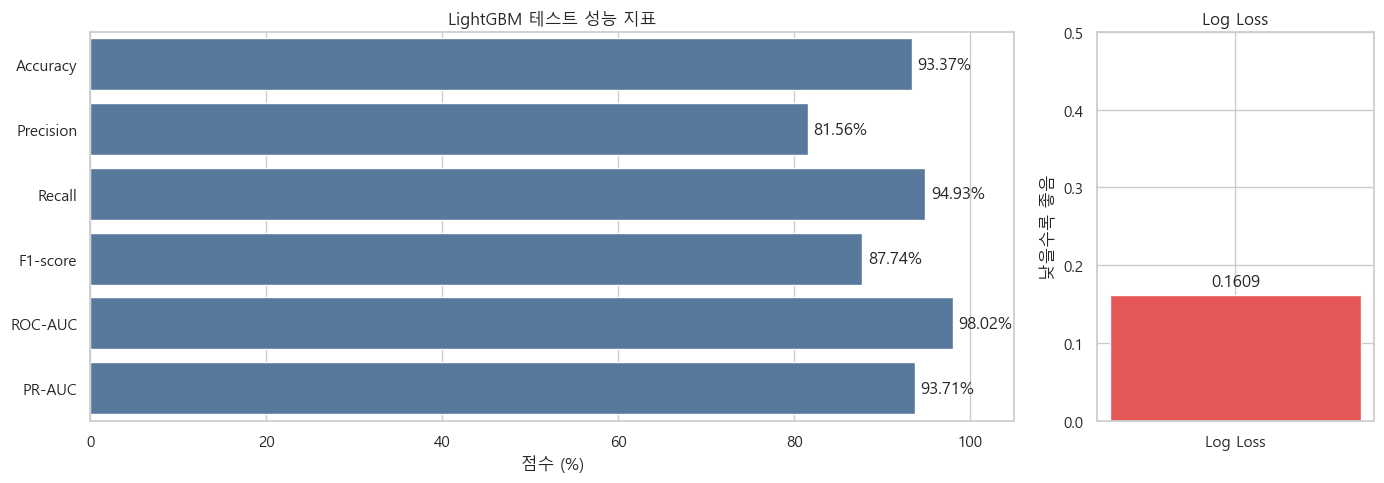

이미지 저장: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\visualizations\LightGBM\02_confusion_matrix_normalized.png


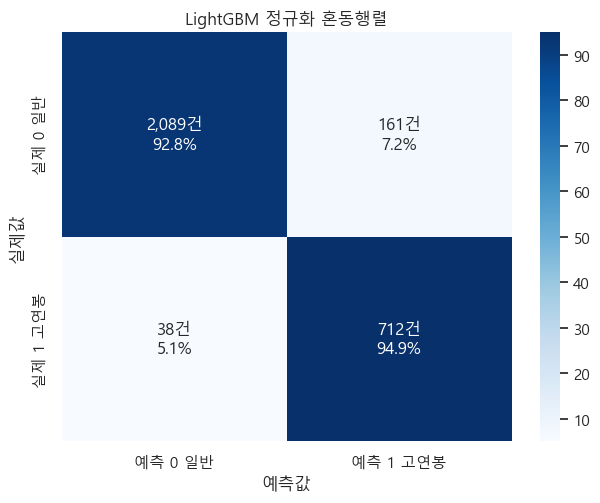

이미지 저장: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\visualizations\LightGBM\03_evaluation_dashboard.png


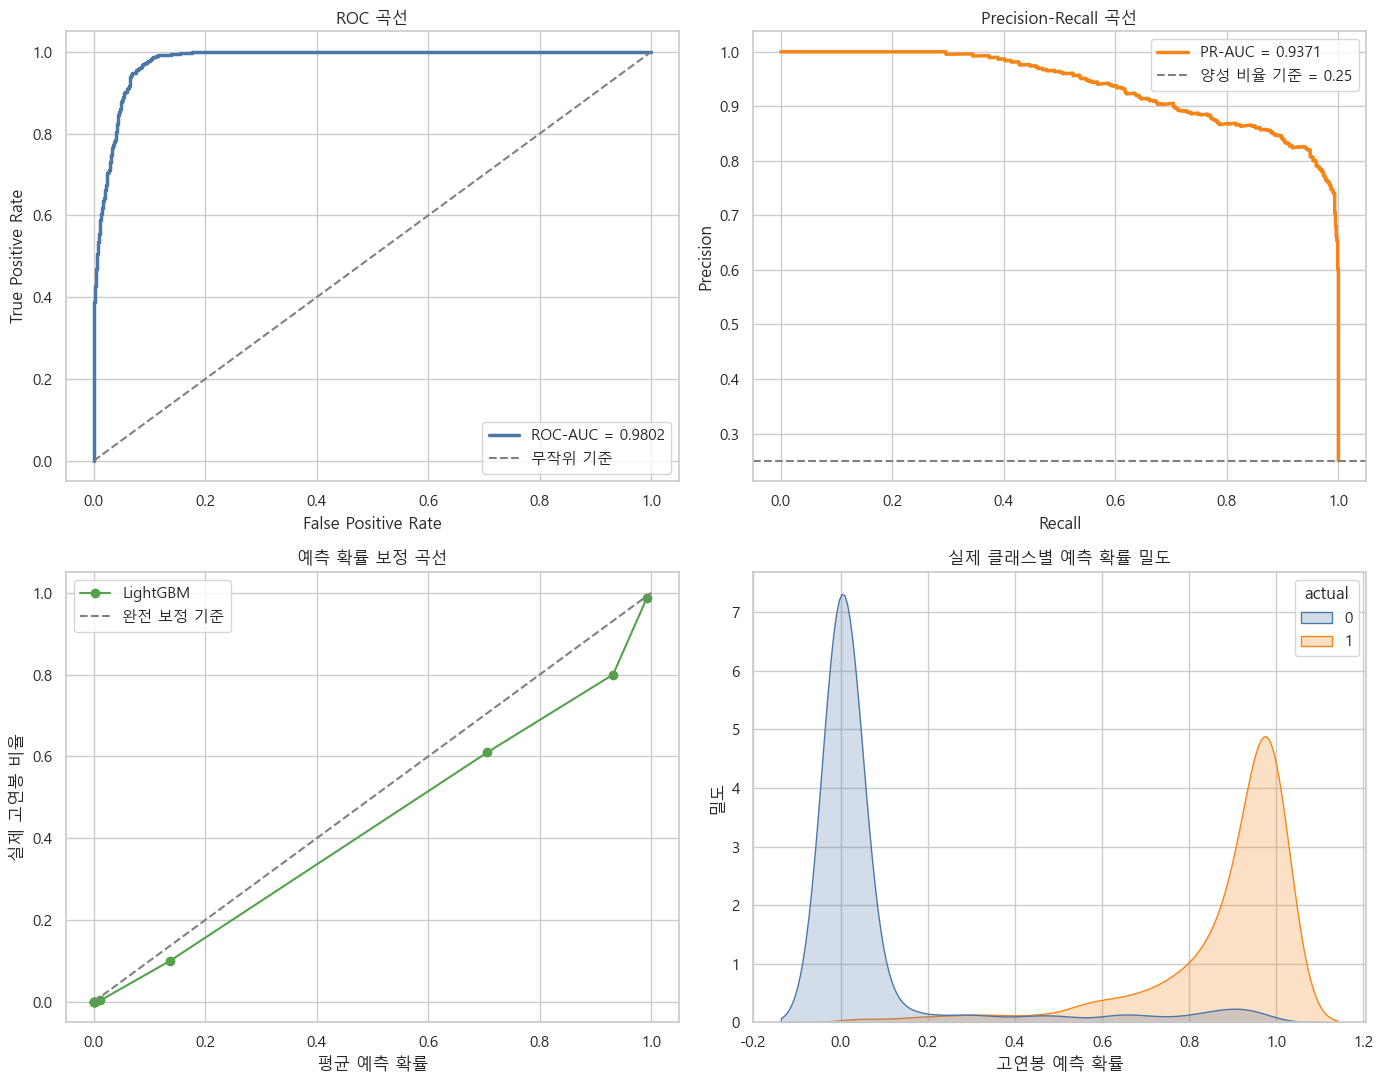

이미지 저장: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\visualizations\LightGBM\04_threshold_performance.png


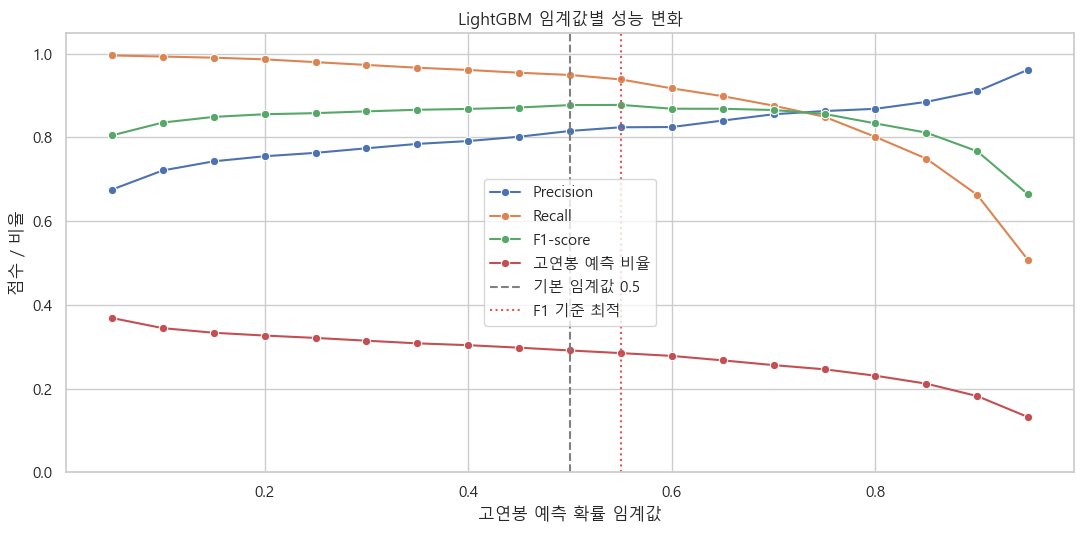

이미지 저장: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\visualizations\LightGBM\05_feature_importance_dashboard.png


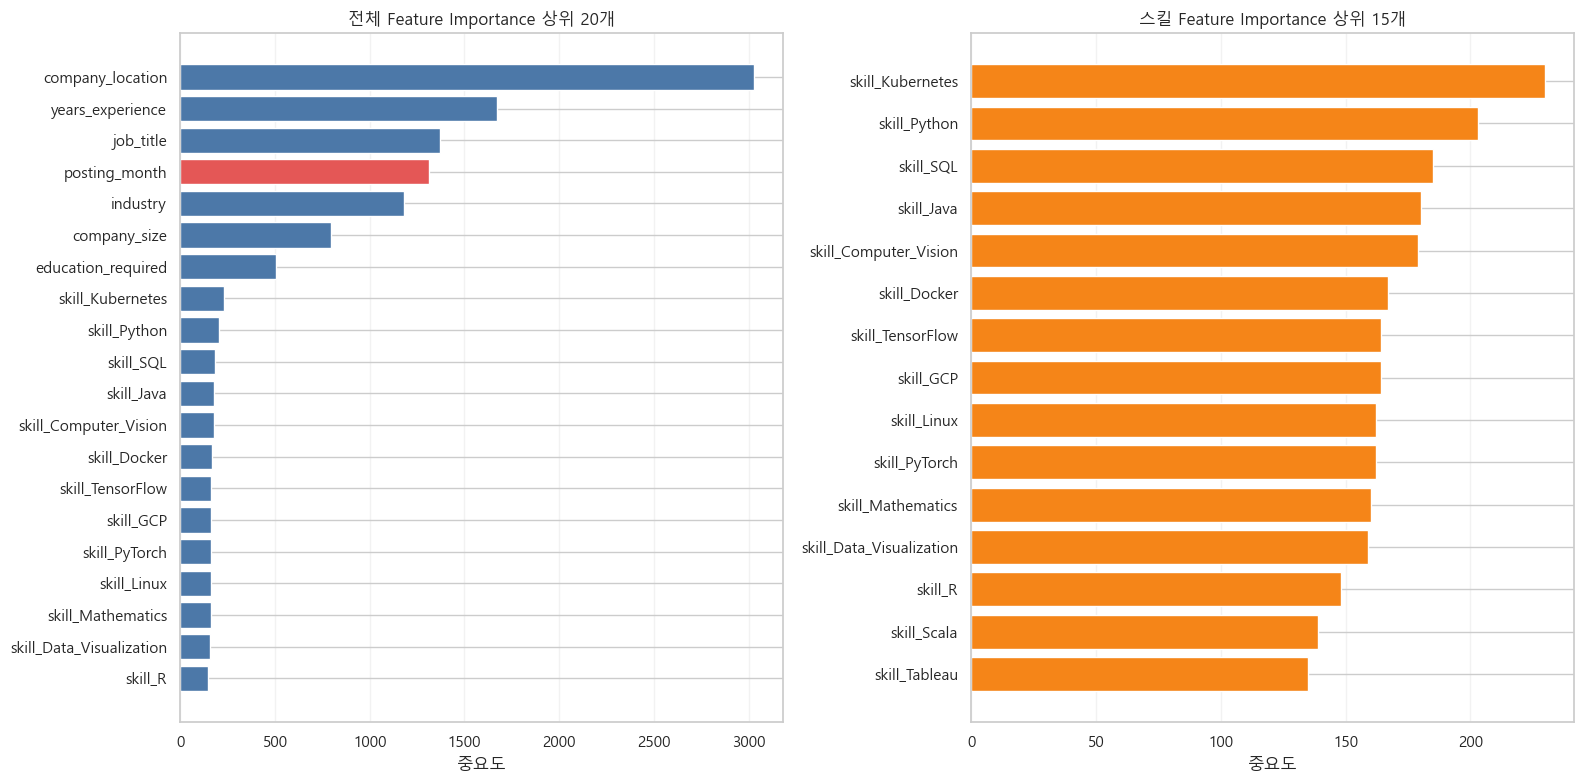

이미지 저장: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\visualizations\LightGBM\06_monthly_prediction_trend.png


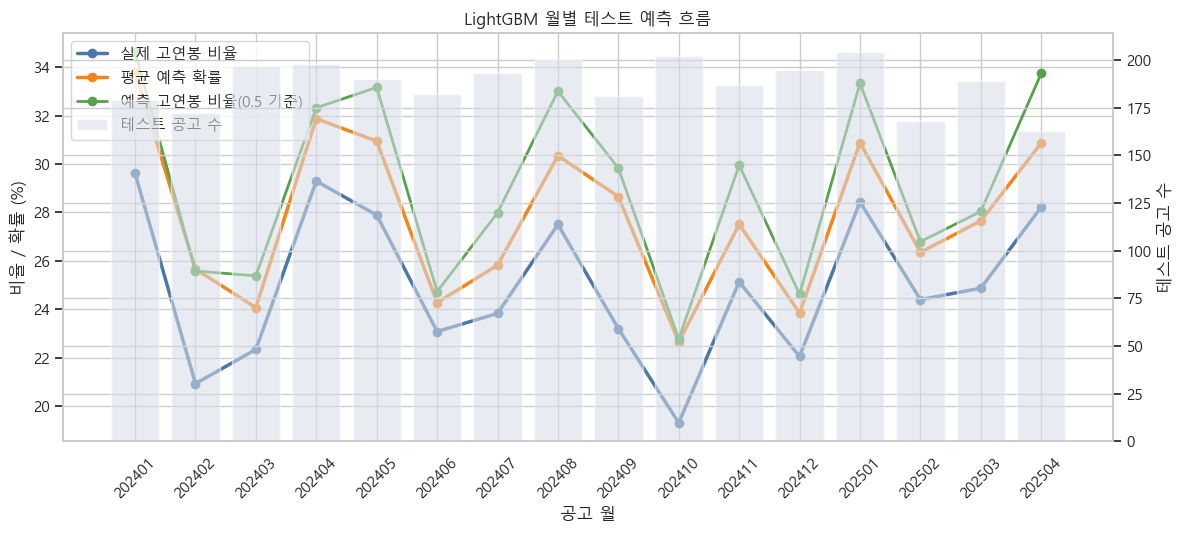

이미지 저장: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\visualizations\LightGBM\07_stratified_kfold_summary.png


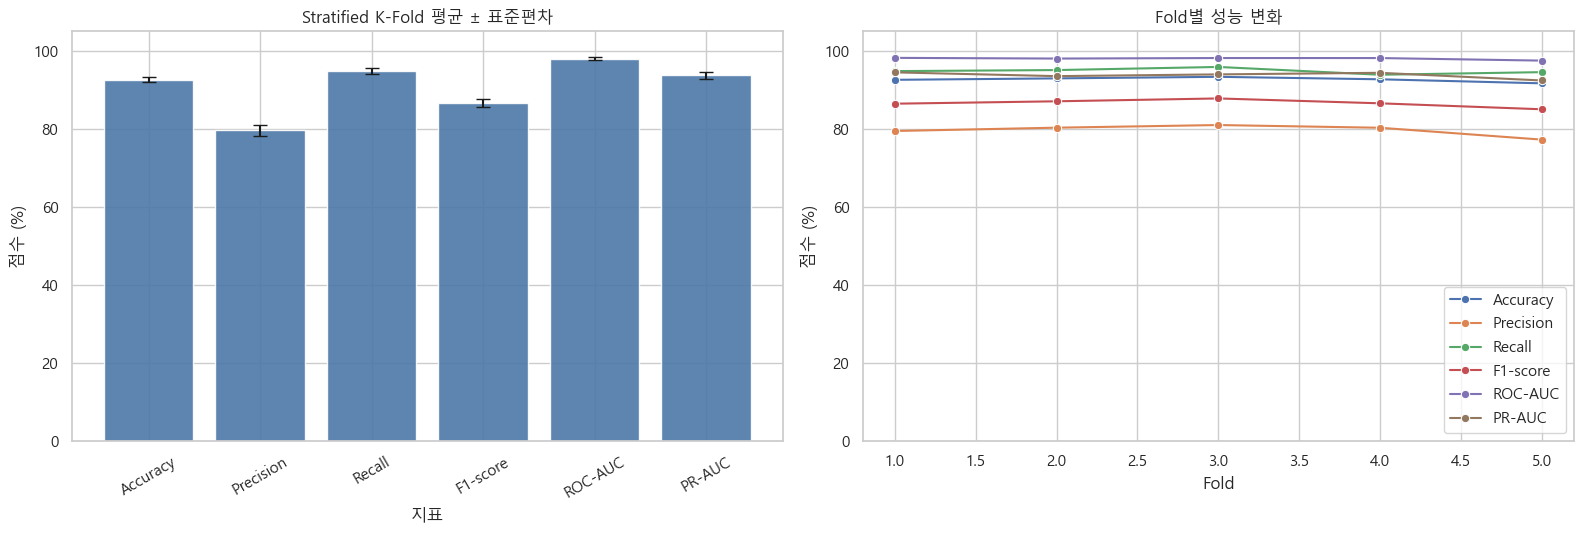

시각화 이미지 저장 폴더: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\visualizations\LightGBM


In [16]:
visual_dir = OUTPUT_DIR / "visualizations" / MODEL_NAME
visual_dir.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename):
    path = visual_dir / filename
    fig.savefig(path, dpi=180, bbox_inches="tight", facecolor="white")
    print(f"이미지 저장: {path}")


# 1) 성능 지표 막대그래프
score_metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]
metrics_score_df = metrics_df[metrics_df["Metric"].isin(score_metrics)].copy()
metrics_score_df["Value_%"] = metrics_score_df["Value"] * 100
log_loss_value = metrics_df.loc[metrics_df["Metric"] == "Log Loss", "Value"].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [4, 1.2]})
sns.barplot(data=metrics_score_df, y="Metric", x="Value_%", ax=axes[0], color="#4C78A8")
axes[0].set_title(f"{MODEL_NAME} 테스트 성능 지표")
axes[0].set_xlabel("점수 (%)")
axes[0].set_ylabel("")
axes[0].set_xlim(0, 105)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f%%", padding=4)

axes[1].bar(["Log Loss"], [log_loss_value], color="#E45756")
axes[1].set_title("Log Loss")
axes[1].set_ylim(0, max(0.5, log_loss_value * 1.35))
axes[1].bar_label(axes[1].containers[0], fmt="%.4f", padding=4)
axes[1].set_ylabel("낮을수록 좋음")
plt.tight_layout()
save_figure(fig, "01_test_metrics_bar.png")
plt.show()


# 2) 정규화 혼동행렬
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
annot_labels = np.empty_like(cm).astype(object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot_labels[i, j] = f"{cm[i, j]:,}건\n{cm_percent[i, j]:.1f}%"

fig, ax = plt.subplots(figsize=(6.5, 5.2))
sns.heatmap(
    cm_percent,
    annot=annot_labels,
    fmt="",
    cmap="Blues",
    cbar=True,
    xticklabels=["예측 0 일반", "예측 1 고연봉"],
    yticklabels=["실제 0 일반", "실제 1 고연봉"],
    ax=ax,
)
ax.set_title(f"{MODEL_NAME} 정규화 혼동행렬")
ax.set_xlabel("예측값")
ax.set_ylabel("실제값")
plt.tight_layout()
save_figure(fig, "02_confusion_matrix_normalized.png")
plt.show()


# 3) ROC / PR / 보정 / 확률 분포 통합 대시보드
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

axes[0, 0].plot(fpr, tpr, color="#4C78A8", linewidth=2.5, label=f"ROC-AUC = {roc_auc:.4f}")
axes[0, 0].plot([0, 1], [0, 1], color="gray", linestyle="--", label="무작위 기준")
axes[0, 0].set_title("ROC 곡선")
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].legend(loc="lower right")

axes[0, 1].plot(recall_curve, precision_curve, color="#F58518", linewidth=2.5, label=f"PR-AUC = {pr_auc:.4f}")
axes[0, 1].axhline(y_test.mean(), color="gray", linestyle="--", label=f"양성 비율 기준 = {y_test.mean():.2f}")
axes[0, 1].set_title("Precision-Recall 곡선")
axes[0, 1].set_xlabel("Recall")
axes[0, 1].set_ylabel("Precision")
axes[0, 1].legend(loc="upper right")

axes[1, 0].plot(prob_pred, prob_true, marker="o", color="#54A24B", label=MODEL_NAME)
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="완전 보정 기준")
axes[1, 0].set_title("예측 확률 보정 곡선")
axes[1, 0].set_xlabel("평균 예측 확률")
axes[1, 0].set_ylabel("실제 고연봉 비율")
axes[1, 0].legend()

sns.kdeplot(
    data=probability_df,
    x="predicted_probability",
    hue="actual",
    common_norm=False,
    fill=True,
    alpha=0.25,
    ax=axes[1, 1],
    palette=["#4C78A8", "#F58518"],
)
axes[1, 1].set_title("실제 클래스별 예측 확률 밀도")
axes[1, 1].set_xlabel("고연봉 예측 확률")
axes[1, 1].set_ylabel("밀도")

plt.tight_layout()
save_figure(fig, "03_evaluation_dashboard.png")
plt.show()


# 4) 임계값별 성능 변화
threshold_plot_df = threshold_df.melt(
    id_vars="threshold",
    value_vars=["precision", "recall", "f1", "predicted_positive_rate"],
    var_name="metric",
    value_name="value",
)
threshold_label_map = {
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1-score",
    "predicted_positive_rate": "고연봉 예측 비율",
}
threshold_plot_df["metric"] = threshold_plot_df["metric"].map(threshold_label_map)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.lineplot(data=threshold_plot_df, x="threshold", y="value", hue="metric", marker="o", ax=ax)
ax.axvline(0.5, color="gray", linestyle="--", label="기본 임계값 0.5")
ax.axvline(best_threshold_row["threshold"], color="#E45756", linestyle=":", label="F1 기준 최적")
ax.set_title(f"{MODEL_NAME} 임계값별 성능 변화")
ax.set_xlabel("고연봉 예측 확률 임계값")
ax.set_ylabel("점수 / 비율")
ax.set_ylim(0, 1.05)
ax.legend(loc="best")
plt.tight_layout()
save_figure(fig, "04_threshold_performance.png")
plt.show()


# 5) Feature Importance 시각화 강화
top_feature = feature_importance.head(20).sort_values("importance", ascending=True).copy()
top_colors = ["#E45756" if feature == MONTH_FEATURE else "#4C78A8" for feature in top_feature["feature"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].barh(top_feature["feature"], top_feature["importance"], color=top_colors)
axes[0].set_title("전체 Feature Importance 상위 20개")
axes[0].set_xlabel("중요도")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)

top_skill = skill_importance.head(15).sort_values("importance", ascending=True).copy()
axes[1].barh(top_skill["feature"], top_skill["importance"], color="#F58518")
axes[1].set_title("스킬 Feature Importance 상위 15개")
axes[1].set_xlabel("중요도")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)

plt.tight_layout()
save_figure(fig, "05_feature_importance_dashboard.png")
plt.show()


# 6) 월별 실제 비율과 평균 예측 확률 비교
fig, ax1 = plt.subplots(figsize=(12, 5.5))
ax2 = ax1.twinx()

ax2.bar(
    monthly_test_result[MONTH_FEATURE].astype(str),
    monthly_test_result["테스트공고수"],
    color="#D6DEE8",
    alpha=0.55,
    label="테스트 공고 수",
)
ax1.plot(
    monthly_test_result[MONTH_FEATURE].astype(str),
    monthly_test_result["실제고연봉비율_%"],
    marker="o",
    linewidth=2.5,
    color="#4C78A8",
    label="실제 고연봉 비율",
)
ax1.plot(
    monthly_test_result[MONTH_FEATURE].astype(str),
    monthly_test_result["평균예측확률_%"],
    marker="o",
    linewidth=2.5,
    color="#F58518",
    label="평균 예측 확률",
)
ax1.plot(
    monthly_test_result[MONTH_FEATURE].astype(str),
    monthly_test_result["예측고연봉비율_임계값0_5_%"],
    marker="o",
    linewidth=2,
    color="#54A24B",
    label="예측 고연봉 비율(0.5 기준)",
)
ax1.set_title(f"{MODEL_NAME} 월별 테스트 예측 흐름")
ax1.set_xlabel("공고 월")
ax1.set_ylabel("비율 / 확률 (%)")
ax2.set_ylabel("테스트 공고 수")
ax1.tick_params(axis="x", rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
save_figure(fig, "06_monthly_prediction_trend.png")
plt.show()


# 7) Stratified K-Fold 평균과 Fold별 변화
cv_plot_metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]
cv_summary_plot = cv_summary[cv_summary["Metric"].isin(cv_plot_metrics)].copy()
cv_summary_plot["Mean_%"] = cv_summary_plot["Mean"] * 100
cv_summary_plot["Std_%"] = cv_summary_plot["Std"] * 100

cv_long = cv_df.melt(
    id_vars="fold",
    value_vars=cv_plot_metrics,
    var_name="Metric",
    value_name="Value",
)
cv_long["Value_%"] = cv_long["Value"] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
axes[0].bar(
    cv_summary_plot["Metric"],
    cv_summary_plot["Mean_%"],
    yerr=cv_summary_plot["Std_%"],
    capsize=5,
    color="#4C78A8",
    alpha=0.9,
)
axes[0].set_title("Stratified K-Fold 평균 ± 표준편차")
axes[0].set_xlabel("지표")
axes[0].set_ylabel("점수 (%)")
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis="x", rotation=30)

sns.lineplot(data=cv_long, x="fold", y="Value_%", hue="Metric", marker="o", ax=axes[1])
axes[1].set_title("Fold별 성능 변화")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("점수 (%)")
axes[1].set_ylim(0, 105)
axes[1].legend(loc="lower right")

plt.tight_layout()
save_figure(fig, "07_stratified_kfold_summary.png")
plt.show()

print(f"시각화 이미지 저장 폴더: {visual_dir}")

## 16. SHAP 분석

SHAP 분석은 모델이 어떤 변수를 근거로 예측했는지 설명하는 방법입니다.  
Feature Importance가 “모델 전체에서 어떤 변수를 많이 참고했는지”를 보여준다면, SHAP은 “각 변수가 예측 확률을 높이는 방향으로 작용했는지, 낮추는 방향으로 작용했는지”까지 볼 수 있습니다.

- SHAP 중요도 막대그래프: 전체적으로 영향이 큰 변수 확인
- SHAP Beeswarm Plot: 변수값이 예측을 높이는지 낮추는지 방향 확인
- SHAP Dependence Plot: 가장 중요한 변수의 값 변화와 SHAP 값 관계 확인
- 개별 예측 SHAP 분석: 고연봉 예측 확률이 가장 높은 테스트 샘플 1건의 근거 확인

주의: SHAP 값도 인과관계가 아닙니다. “모델이 이 데이터에서 예측할 때 활용한 패턴”으로 해석해야 합니다.

SHAP 분석 샘플 수: 500
SHAP 값 배열 크기: (500, 32)


,feature,mean_abs_shap
0,years_experience,4.117217
4,company_size,1.223860
6,company_location,1.213417
2,experience_level,0.536568
1,posting_month,0.100198
7,industry,0.096743
3,education_required,0.094489
5,job_title,0.085624
18,skill_Kubernetes,0.049625
17,skill_Java,0.037415


이미지 저장: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\visualizations\LightGBM\08_shap_importance_bar.png


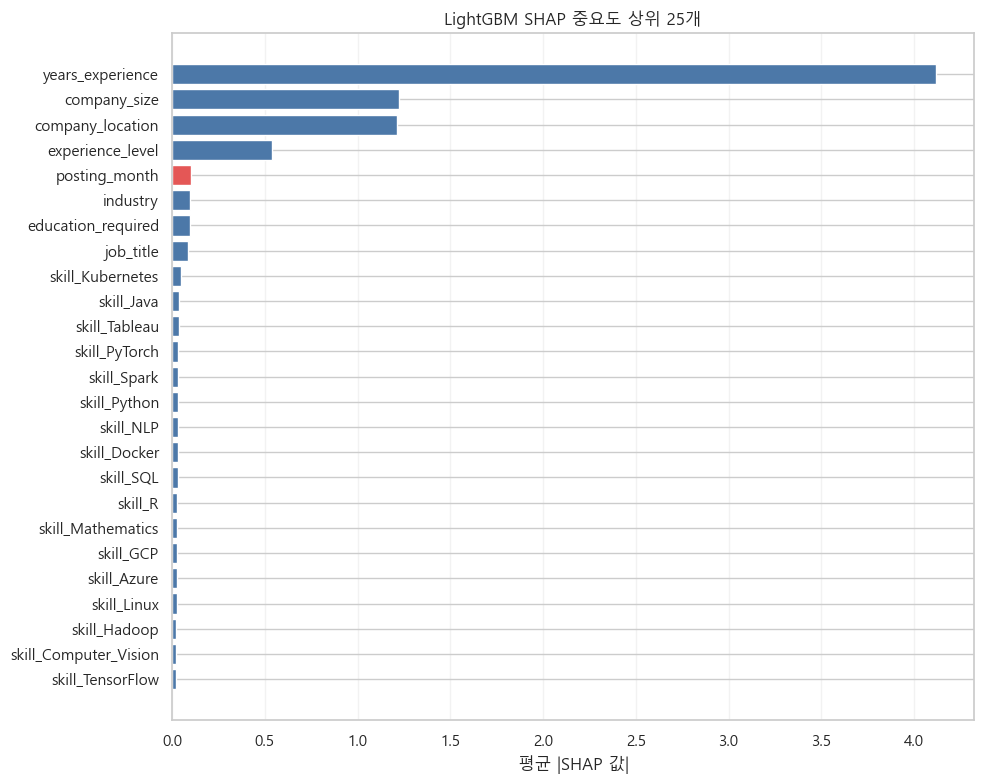

이미지 저장: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\visualizations\LightGBM\09_shap_beeswarm.png


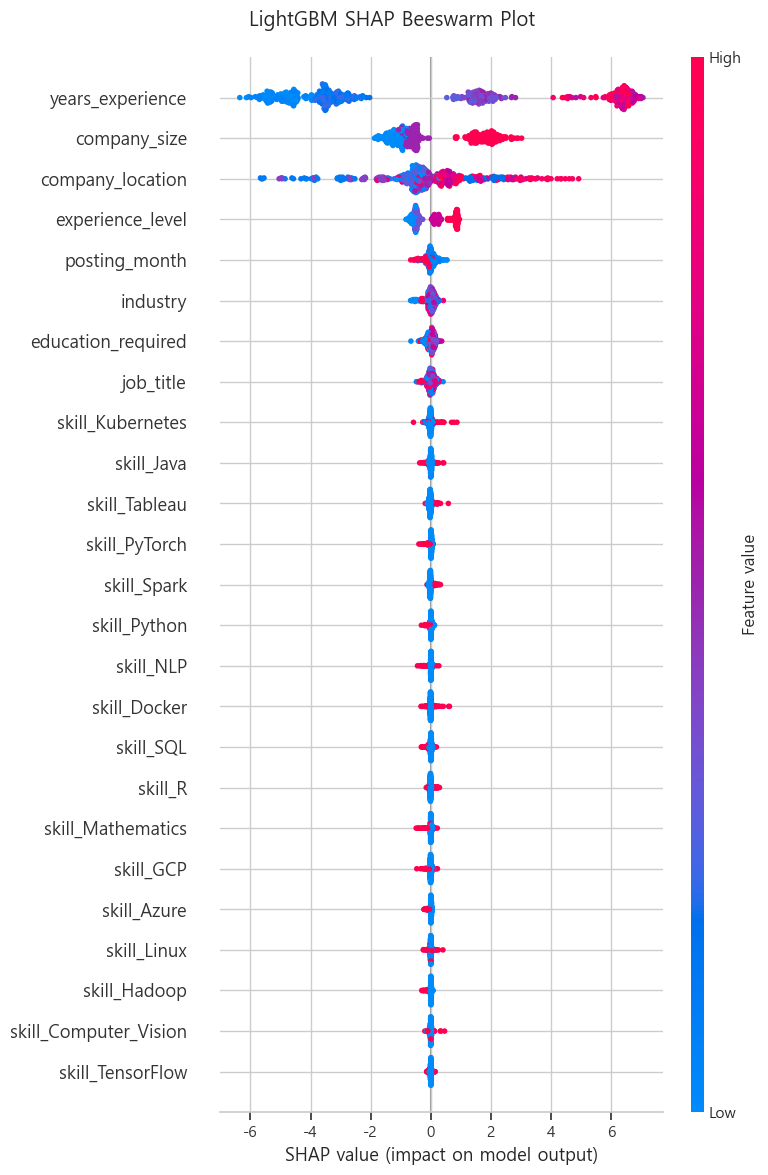

이미지 저장: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\visualizations\LightGBM\10_shap_dependence_top_feature.png


<Figure size 900x600 with 0 Axes>

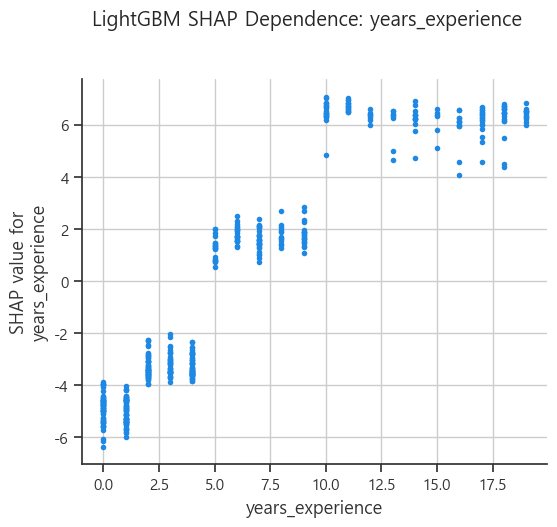

,feature,value,shap_value,abs_shap
0,years_experience,11,6.676927,6.676927
6,company_location,13,2.823590,2.823590
4,company_size,2,1.659692,1.659692
2,experience_level,3,0.882973,0.882973
17,skill_Java,1,-0.109286,0.109286
13,skill_Docker,0,0.050626,0.050626
7,industry,4,0.043804,0.043804
21,skill_Mathematics,1,-0.040430,0.040430
30,skill_Tableau,0,0.036666,0.036666
24,skill_Python,0,0.035940,0.035940


이미지 저장: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\visualizations\LightGBM\11_shap_local_explanation.png


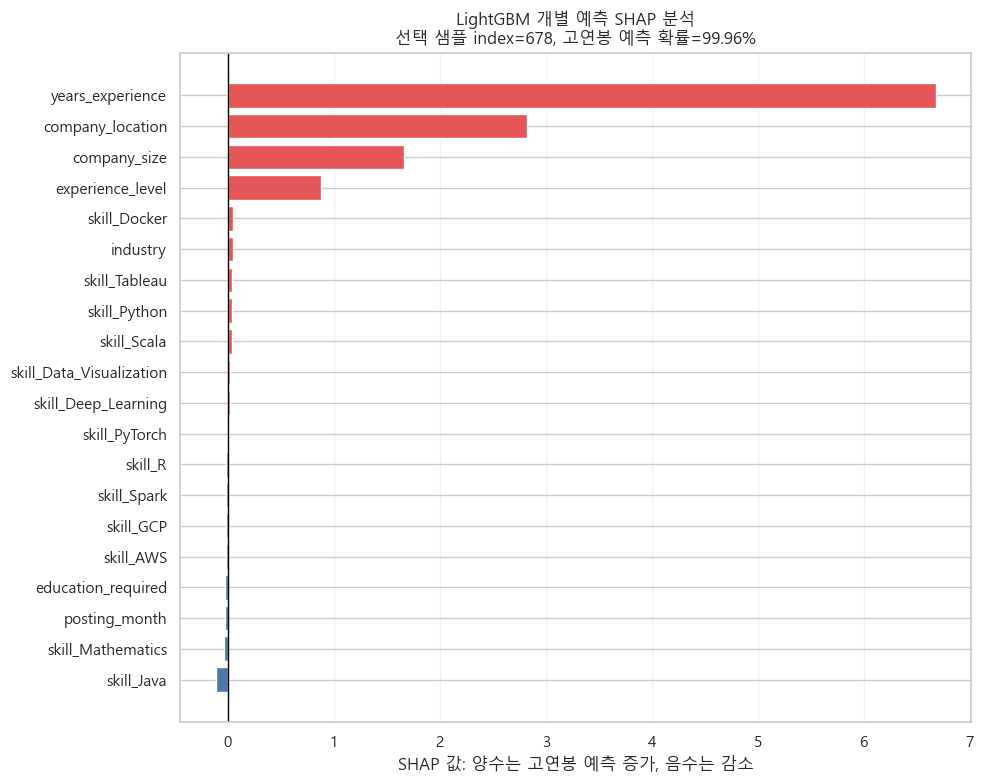

SHAP 분석 결과 저장 완료
SHAP 중요도 CSV: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\model_artifacts\LightGBM_RandomSplit_Month_shap_importance.csv
개별 예측 SHAP CSV: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\model_artifacts\LightGBM_RandomSplit_Month_shap_local_example.csv
SHAP 이미지 저장 폴더: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\visualizations\LightGBM


In [17]:
import shap

if "visual_dir" not in globals():
    visual_dir = OUTPUT_DIR / "visualizations" / MODEL_NAME
    visual_dir.mkdir(parents=True, exist_ok=True)

if "save_figure" not in globals():
    def save_figure(fig, filename):
        path = visual_dir / filename
        fig.savefig(path, dpi=180, bbox_inches="tight", facecolor="white")
        print(f"이미지 저장: {path}")


# SHAP은 계산량이 큰 편이므로 테스트 데이터 일부만 샘플링합니다.
shap_sample_size = min(500, len(X_test))
X_shap = X_test.sample(n=shap_sample_size, random_state=RANDOM_STATE).copy()

# 그래프 색상 표현을 위해 코드형 범주 변수도 숫자형으로 변환한 표시용 데이터프레임을 만듭니다.
X_shap_plot = X_shap.copy()
for col in X_shap_plot.columns:
    X_shap_plot[col] = pd.to_numeric(X_shap_plot[col], errors="coerce").fillna(-1)


if MODEL_NAME == "CatBoost":
    shap_pool = Pool(X_shap, cat_features=categorical_cols)
    raw_shap_values = model.get_feature_importance(shap_pool, type="ShapValues")
    shap_values = raw_shap_values[:, :-1]
    expected_value = float(np.mean(raw_shap_values[:, -1]))
else:
    explainer = shap.TreeExplainer(model)
    raw_shap_values = explainer.shap_values(X_shap_plot)

    if isinstance(raw_shap_values, list):
        shap_values = raw_shap_values[1] if len(raw_shap_values) > 1 else raw_shap_values[0]
    elif isinstance(raw_shap_values, np.ndarray) and raw_shap_values.ndim == 3:
        shap_values = raw_shap_values[:, :, 1]
    else:
        shap_values = raw_shap_values

    expected_raw = explainer.expected_value
    if isinstance(expected_raw, (list, np.ndarray)):
        expected_value = float(np.ravel(expected_raw)[-1])
    else:
        expected_value = float(expected_raw)

shap_values = np.asarray(shap_values)
print(f"SHAP 분석 샘플 수: {len(X_shap):,}")
print(f"SHAP 값 배열 크기: {shap_values.shape}")


# 1) SHAP 평균 절대값 중요도
shap_importance = pd.DataFrame(
    {
        "feature": feature_cols,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    }
).sort_values("mean_abs_shap", ascending=False)

display(shap_importance.head(30).round(6))

fig, ax = plt.subplots(figsize=(10, 8))
top_shap = shap_importance.head(25).sort_values("mean_abs_shap", ascending=True)
colors = ["#E45756" if feature == MONTH_FEATURE else "#4C78A8" for feature in top_shap["feature"]]
ax.barh(top_shap["feature"], top_shap["mean_abs_shap"], color=colors)
ax.set_title(f"{MODEL_NAME} SHAP 중요도 상위 25개")
ax.set_xlabel("평균 |SHAP 값|")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
save_figure(fig, "08_shap_importance_bar.png")
plt.show()


# 2) SHAP Beeswarm Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_shap_plot,
    feature_names=feature_cols,
    max_display=25,
    show=False,
)
fig = plt.gcf()
fig.suptitle(f"{MODEL_NAME} SHAP Beeswarm Plot", y=1.02)
save_figure(fig, "09_shap_beeswarm.png")
plt.show()


# 3) 가장 중요한 변수의 SHAP Dependence Plot
top_shap_feature = shap_importance.iloc[0]["feature"]
plt.figure(figsize=(9, 6))
shap.dependence_plot(
    top_shap_feature,
    shap_values,
    X_shap_plot,
    feature_names=feature_cols,
    interaction_index=None,
    show=False,
)
fig = plt.gcf()
fig.suptitle(f"{MODEL_NAME} SHAP Dependence: {top_shap_feature}", y=1.02)
save_figure(fig, "10_shap_dependence_top_feature.png")
plt.show()


# 4) 고연봉 예측 확률이 가장 높은 테스트 샘플 1건의 로컬 SHAP 분석
proba_series = pd.Series(y_pred_proba, index=X_test.index)
selected_index = proba_series.loc[X_shap.index].idxmax()
selected_position = list(X_shap.index).index(selected_index)
selected_probability = float(proba_series.loc[selected_index])

local_shap = pd.DataFrame(
    {
        "feature": feature_cols,
        "value": X_shap.loc[selected_index].astype(str).values,
        "shap_value": shap_values[selected_position],
    }
)
local_shap["abs_shap"] = local_shap["shap_value"].abs()
local_shap_top = local_shap.sort_values("abs_shap", ascending=False).head(20).sort_values("shap_value")

display(local_shap.sort_values("abs_shap", ascending=False).head(20).round(6))

fig, ax = plt.subplots(figsize=(10, 8))
local_colors = ["#E45756" if value > 0 else "#4C78A8" for value in local_shap_top["shap_value"]]
ax.barh(local_shap_top["feature"], local_shap_top["shap_value"], color=local_colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title(
    f"{MODEL_NAME} 개별 예측 SHAP 분석\n"
    f"선택 샘플 index={selected_index}, 고연봉 예측 확률={selected_probability:.2%}"
)
ax.set_xlabel("SHAP 값: 양수는 고연봉 예측 증가, 음수는 감소")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
save_figure(fig, "11_shap_local_explanation.png")
plt.show()


# 5) SHAP 결과 저장
artifact_dir = OUTPUT_DIR / "model_artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)
shap_importance_path = artifact_dir / f"{MODEL_NAME}_RandomSplit_Month_shap_importance.csv"
local_shap_path = artifact_dir / f"{MODEL_NAME}_RandomSplit_Month_shap_local_example.csv"
shap_importance.to_csv(shap_importance_path, index=False, encoding="utf-8-sig")
local_shap.sort_values("abs_shap", ascending=False).to_csv(local_shap_path, index=False, encoding="utf-8-sig")

print("SHAP 분석 결과 저장 완료")
print(f"SHAP 중요도 CSV: {shap_importance_path}")
print(f"개별 예측 SHAP CSV: {local_shap_path}")
print(f"SHAP 이미지 저장 폴더: {visual_dir}")

## 17. 모델 및 결과 저장

            학습된 모델과 주요 결과 표를 별도 폴더에 저장합니다.  
            노트북을 다시 실행하면 같은 위치에 최신 결과로 갱신됩니다.

In [18]:
import joblib

artifact_dir = OUTPUT_DIR / "model_artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)

model_path = artifact_dir / "LightGBM_RandomSplit_Month.joblib"
metrics_path = artifact_dir / "LightGBM_RandomSplit_Month_metrics.csv"
feature_importance_path = artifact_dir / "LightGBM_RandomSplit_Month_feature_importance.csv"
monthly_result_path = artifact_dir / "LightGBM_RandomSplit_Month_monthly_test_result.csv"
threshold_path = artifact_dir / "LightGBM_RandomSplit_Month_threshold_metrics.csv"

joblib.dump(model, model_path)
metrics_df.to_csv(metrics_path, index=False, encoding="utf-8-sig")
feature_importance.to_csv(feature_importance_path, index=False, encoding="utf-8-sig")
monthly_test_result.to_csv(monthly_result_path, index=False, encoding="utf-8-sig")
threshold_df.to_csv(threshold_path, index=False, encoding="utf-8-sig")

print("저장 완료")
print(f"모델 파일: {model_path}")
print(f"성능 지표 CSV: {metrics_path}")
print(f"Feature Importance CSV: {feature_importance_path}")
print(f"월별 테스트 결과 CSV: {monthly_result_path}")
print(f"임계값별 지표 CSV: {threshold_path}")

저장 완료
모델 파일: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\model_artifacts\LightGBM_RandomSplit_Month.joblib
성능 지표 CSV: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\model_artifacts\LightGBM_RandomSplit_Month_metrics.csv
Feature Importance CSV: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\model_artifacts\LightGBM_RandomSplit_Month_feature_importance.csv
월별 테스트 결과 CSV: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\model_artifacts\LightGBM_RandomSplit_Month_monthly_test_result.csv
임계값별 지표 CSV: C:\Users\rdp-user\Desktop\3Team\05_month_modeling_no_quarter\model_artifacts\LightGBM_RandomSplit_Month_threshold_metrics.csv


## 최종 해석 메모

            - 이 노트북의 모델은 `LightGBM`입니다.
            - 예측 목표는 `high_salary`입니다.
            - `posting_month`는 월 기준 모델 입력 변수로 포함했습니다.
            - `quarter`는 입력 변수에서 제외했습니다.
            - 평가지표, 혼동행렬, ROC/PR 곡선, 임계값별 성능, 보정 곡선, 학습 곡선, Feature Importance, 월별 테스트 예측 결과, Stratified K-Fold 교차검증, 발표/노션용 저장 이미지, SHAP 분석을 확인했습니다.
            - Feature Importance는 인과관계가 아니라 “모델이 예측에 참고한 정도”입니다.